In [1]:
import os
import joblib

from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss

import numpy as np
import matplotlib.pyplot as plt

import torch

## Datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [3]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = False      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [4]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [5]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [6]:
all_params[cond][200:300, :][0]

tensor([ 1.6378e+00,  1.2637e+00,  5.0738e-01,  2.0978e-01,  5.2745e-02,
         1.1210e-01,  1.0870e-01,  7.2354e-02, -1.0365e-01, -2.5467e-01,
        -2.5914e-01, -1.7284e-01,  2.0227e+00, -3.9245e-01,  7.4644e-01,
         5.3680e-01, -1.4159e+00,  1.6089e+00, -9.9473e-01, -6.9557e-01,
        -2.5483e-02,  1.1225e-01,  4.6407e-03,  1.7892e-02, -3.7551e-01,
        -1.7522e+00, -6.5756e-03, -2.5166e-02,  1.9776e+00, -3.2318e+00,
         1.1493e-02, -1.3138e-02, -2.7263e-01,  5.6275e-01, -2.9823e-03,
         3.4148e-03, -2.3459e+00, -3.1492e+00, -4.6431e-01, -1.9093e+00,
        -1.5528e+00, -7.4330e-01, -4.1667e-01, -1.7053e+00,  4.2772e+00,
         1.9020e-01,  2.4109e-01, -5.0694e-01, -8.4565e-01, -4.7361e-01,
        -6.6536e-02,  1.3278e-01,  1.0777e+00, -1.3830e+00,  5.1050e-02,
        -9.1706e-02, -1.1412e+00,  2.3117e+00,  2.9825e-02, -5.2348e-02,
         7.8197e-01,  2.8879e+00, -1.3470e-02,  1.2029e-02, -7.2061e-01,
         2.6525e+00, -7.5809e-03,  6.7368e-03, -1.2

In [7]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7489, std: 0.0009
C=0.1 , l1=0.5, mean: 0.7520, std: 0.0008
C=0.1 , l1=1.0, mean: 0.7472, std: 0.0017
C=1.0 , l1=0.0, mean: 0.7474, std: 0.0010
C=1.0 , l1=0.5, mean: 0.7458, std: 0.0011
C=1.0 , l1=1.0, mean: 0.7457, std: 0.0011
C=10.0, l1=0.0, mean: 0.7454, std: 0.0011
C=10.0, l1=0.5, mean: nan, std: nan
C=10.0, l1=1.0, mean: nan, std: nan


/tmp/ipykernel_19193/1178497271.py:6: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969073/work/aten/src/ATen/native/ReduceOps.cpp:1807.)
  print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')


In [8]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7423, std: 0.0004
C=0.1 , l1=0.5, mean: 0.7425, std: 0.0004
C=0.1 , l1=1.0, mean: 0.7409, std: 0.0005
C=1.0 , l1=0.0, mean: 0.7413, std: 0.0005
C=1.0 , l1=0.5, mean: 0.7404, std: 0.0005
C=1.0 , l1=1.0, mean: 0.7406, std: 0.0005
C=10.0, l1=0.0, mean: 0.7407, std: 0.0005
C=10.0, l1=0.5, mean: nan, std: nan
C=10.0, l1=1.0, mean: nan, std: nan


/tmp/ipykernel_19193/1350017468.py:6: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1716905969073/work/aten/src/ATen/native/ReduceOps.cpp:1807.)
  print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, std: {aux.std().item():.4f}')


### Accuracies on all datasets

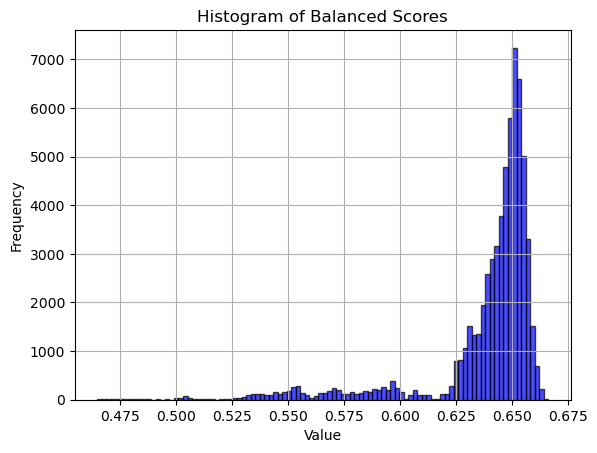

In [9]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

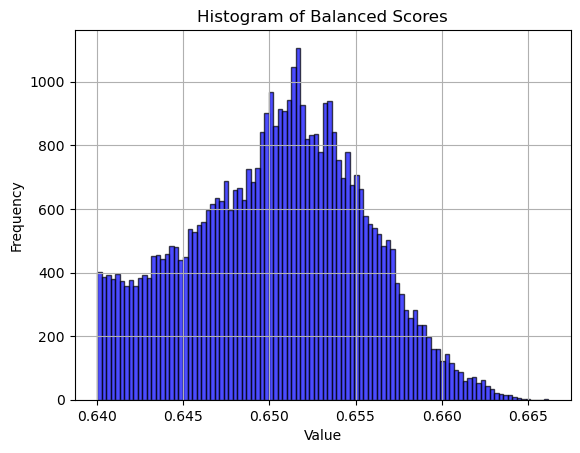

In [10]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [11]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [12]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [13]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

F1-score: 0.7250808445881681

Confusion Matrix for Class 0 - Chowell_train:
[[0.94487847 0.05512153]
 [0.06948846 0.93051154]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.93638677 0.06361323]
 [0.04918794 0.95081206]]

Confusion Matrix for Class 2 - MSK1:
[[0.92860581 0.07139419]
 [0.29394916 0.70605084]]

Confusion Matrix for Class 3 - MSK2:
[[0.9433623  0.0566377 ]
 [0.39370748 0.60629252]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.95658404 0.04341596]
 [0.66243283 0.33756717]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.97421784 0.02578216]
 [0.85673893 0.14326107]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.96129326 0.03870674]
 [0.81255127 0.18744873]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.94827093 0.05172907]
 [0.4117357  0.5882643 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.97786228 0.02213772]
 [0.4016837  0.5983163 ]]


              precision    recall  f1-score   support

           0       0.94      0.93      0.94      4418

### Strong (AUC scores)

In [14]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [15]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

F1-score: 0.794786003067057

Confusion Matrix for Class 0 - Chowell_train:
[[0.99869792 0.00130208]
 [0.         1.        ]]

Confusion Matrix for Class 1 - Chowell_test:
[[1.         0.        ]
 [0.02064965 0.97935035]]

Confusion Matrix for Class 2 - MSK1:
[[0.98844858 0.01155142]
 [0.18188328 0.81811672]]

Confusion Matrix for Class 3 - MSK2:
[[0.9625412  0.0374588 ]
 [0.52763605 0.47236395]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.9636051  0.0363949 ]
 [0.39130435 0.60869565]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.92844728 0.07155272]
 [0.49481621 0.50518379]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.95598057 0.04401943]
 [0.8314192  0.1685808 ]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.95813089 0.04186911]
 [0.42998028 0.57001972]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.98573951 0.01426049]
 [0.288635   0.711365  ]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4418


## White-box attack ensemble

In [16]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [17]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.7111


In [18]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.17862392384685377

Confusion Matrix for Class 0 - Chowell_train:
[[0.76475694 0.23524306]
 [0.66613852 0.33386148]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.84732824 0.15267176]
 [0.78190255 0.21809745]]

Confusion Matrix for Class 2 - MSK1:
[[0.99679127 0.00320873]
 [0.95631937 0.04368063]]

Confusion Matrix for Class 3 - MSK2:
[[9.99100989e-01 8.99011088e-04]
 [9.96173469e-01 3.82653061e-03]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[9.99856713e-01 1.43287004e-04]
 [1.00000000e+00 0.00000000e+00]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.99840672 0.00159328]
 [0.99811499 0.00188501]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[9.99544627e-01 4.55373406e-04]
 [9.99589828e-01 4.10172272e-04]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[9.99285510e-01 7.14489854e-04]
 [9.99506903e-01 4.93096647e-04]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[9.99864186e-01 1.35814206e-04]
 [1.00000000e+00 0.00000000e+00]]


              precision    

### Evaluate LORIS

In [19]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [95]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [ ]:
classify_by_dataset(loaded_models, X_loris)

### Check other models

In [20]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([114, 168])


tensor([[ 1.1482e+00, -1.7171e+00,  1.6429e+00, -3.6283e-04,  5.8926e-04,
          2.8948e-03,  2.6896e-05,  7.5112e-04,  6.7575e-02, -1.2920e-01,
          1.1694e-02,  7.7304e-02, -2.4292e-02, -1.9772e+00, -1.5600e-01,
          6.2982e-01,  3.6864e-01, -1.1560e+00,  1.4971e-02, -8.9120e-02,
          2.5590e+00, -2.8049e-01,  1.0955e-01, -1.4446e-02,  1.4474e+00,
         -1.7718e-01,  2.7979e-02, -3.7051e-03, -8.9966e-02,  2.1939e+00,
          6.5769e-03,  5.0303e-02,  2.0773e-01,  2.3564e+01,  5.0077e-02,
          3.8208e-01, -4.6489e+00, -9.0721e+00,  1.2462e+00, -3.3333e+00,
          7.9365e-01,  6.4329e-01, -1.6747e-01,  4.6805e-01,  5.9787e-01,
          5.8862e-01,  8.3725e-02,  7.0289e-01,  4.0093e-01,  1.8640e+00,
          1.4333e-02,  1.5876e-01,  6.7972e-01,  8.2859e-01,  2.7061e-01,
          7.4056e-01,  2.2096e-01,  7.3038e-01, -3.9336e-02, -1.0573e-01,
          9.9272e+00,  1.5464e+00, -1.0312e+00, -4.2881e-01, -5.8351e+00,
         -1.4792e+00,  3.7729e-01,  1.

In [21]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 0.4058
    Chowell_test: 0.5393
            MSK1: 0.3246
            MSK2: 0.2432
      Shim_NSCLC: 0.1987
  Kato_panCancer: 0.2669
   Vanguri_NSCLC: 0.3100
      Ravi_NSCLC: 0.1993
Pradat_panCancer: 0.1840
